<a href="https://colab.research.google.com/github/rounak-roy-2025/Finance101/blob/rounak-roy-2025-qf/Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portfolio Optimization: Current Holdings vs. Markowitz, Max Sharpe, Min Variance & Black-Litterman

This notebook compares a real NSE portfolio against four optimized allocations:

1. **Mean-Variance Optimization (Markowitz)** — minimum-risk portfolio that targets the same return as the current portfolio
2. **Maximum Sharpe Portfolio (MPT)** — the portfolio on the efficient frontier with the best risk-adjusted return
3. **Minimum Variance Portfolio** — the lowest-risk portfolio achievable from this asset universe
4. **Black-Litterman Model** — blends market equilibrium returns with your personal views

**How to use this notebook:** update the holdings and (optionally) the Black-Litterman views in the **Inputs** section, then use `Runtime > Run all`. Nothing else needs to change.

Data source: Yahoo Finance (`yfinance`), ~5 years of daily adjusted close prices for NSE-listed instruments.

In [2]:
# Install packages not pre-installed on Colab
!pip install -q yfinance PyPortfolioOpt cvxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.3 MB/s eta 0:00:00


In [28]:
import pandas as pd
import numpy as np
import yfinance as yf
import cvxpy as cp
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc

In [5]:
# ---------------------------------------------------------------------------
# HOLDINGS: pulled from the Zerodha holdings statement (Client ID: YSG722, as on 2026-07-03)
# Edit this list whenever your portfolio changes.
# ---------------------------------------------------------------------------
holdings = [
    {"ticker": "ALPL30IETF.NS", "shares": 150, "avg_price": 28.4000},
    {"ticker": "BAJFINANCE.NS", "shares": 20,  "avg_price": 979.6250},
    {"ticker": "BHARTIARTL.NS", "shares": 10,  "avg_price": 1866.8000},
    {"ticker": "BPCL.NS",       "shares": 18,  "avg_price": 285.0000},
    {"ticker": "ICICIBANK.NS",  "shares": 18,  "avg_price": 1369.1667},
    {"ticker": "IRCTC.NS",      "shares": 20,  "avg_price": 552.0000},
    {"ticker": "KPITTECH.NS",   "shares": 8,   "avg_price": 750.6250},
    {"ticker": "MOM30IETF.NS",  "shares": 100, "avg_price": 32.0000},
    {"ticker": "PIDILITIND.NS", "shares": 10,  "avg_price": 1475.0000},
    {"ticker": "RIR.NS",        "shares": 20,  "avg_price": 185.0000},
    {"ticker": "VBL.NS",        "shares": 55,  "avg_price": 428.5455},
]

holdings_df = pd.DataFrame(holdings).set_index("ticker")
tickers = holdings_df.index.tolist()

# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------
LOOKBACK_YEARS = 5          # how much daily history to pull
TRADING_DAYS = 252          # used to annualize daily stats
RISK_FREE_RATE = 0.069      # approx. current Indian 10Y G-Sec yield; update as needed
N_RANDOM_PORTFOLIOS = 5000  # for the Monte Carlo efficient frontier cloud

holdings_df

,shares,avg_price
ticker,,
ALPL30IETF.NS,150,28.4000
BAJFINANCE.NS,20,979.6250
BHARTIARTL.NS,10,1866.8000
BPCL.NS,18,285.0000
ICICIBANK.NS,18,1369.1667
IRCTC.NS,20,552.0000
KPITTECH.NS,8,750.6250
MOM30IETF.NS,100,32.0000
PIDILITIND.NS,10,1475.0000


In [6]:
def download_price_data(ticker_list, years):
    """Download daily adjusted close prices for a list of tickers.

    Returns a DataFrame (dates x tickers). Tickers that fail to download
    are reported and dropped rather than silently breaking the notebook.
    """
    end_date = pd.Timestamp.today()
    start_date = end_date - pd.DateOffset(years=years)

    print(f"Downloading data from {start_date.date()} to {end_date.date()} for {len(ticker_list)} tickers...")

    raw = yf.download(
        ticker_list,
        start=start_date,
        end=end_date,
        auto_adjust=True,   # gives back split/dividend-adjusted 'Close'
        progress=False,
        group_by="ticker",
    )

    prices = pd.DataFrame()
    failed_tickers = []

    for t in ticker_list:
        try:
            series = raw[t]["Close"] if len(ticker_list) > 1 else raw["Close"]
            if series.dropna().empty:
                failed_tickers.append(t)
            else:
                prices[t] = series
        except (KeyError, TypeError):
            failed_tickers.append(t)

    if failed_tickers:
        print(f"WARNING: no data returned for {failed_tickers}. "
              f"Check that these are valid, currently-listed NSE tickers.")

    prices = prices.sort_index()
    return prices, failed_tickers


prices, failed_tickers = download_price_data(tickers, LOOKBACK_YEARS)

# Drop any tickers that failed so the rest of the notebook still runs
tickers = [t for t in tickers if t not in failed_tickers]
holdings_df = holdings_df.loc[tickers]

print(f"\nSuccessfully downloaded {prices.shape[1]} tickers, {prices.shape[0]} trading days.")
prices.tail()

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: RIR.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RIR.NS']: YFTzMissingError('possibly delisted; no timezone found')



Successfully downloaded 10 tickers, 1237 trading days.


,ALPL30IETF.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,ICICIBANK.NS,IRCTC.NS,KPITTECH.NS,MOM30IETF.NS,PIDILITIND.NS,VBL.NS
Date,,,,,,,,,,
2026-06-26,NaN,974.410095,1850.699951,309.750000,1387.500000,514.099976,742.599976,NaN,1597.000000,507.649994
2026-06-29,27.309999,976.049988,1841.099976,300.799988,1387.599976,503.850006,712.200012,32.029999,1599.599976,504.100006
2026-06-30,27.129999,1004.750000,1852.000000,303.549988,1375.199951,502.899994,671.549988,31.469999,1592.699951,507.549988
2026-07-01,27.360001,1014.900024,1871.000000,304.200012,1379.800049,502.700012,557.549988,31.360001,1581.900024,515.700012
2026-07-02,27.520000,1018.400024,1875.000000,310.450012,1400.000000,506.200012,558.799988,31.290001,1605.400024,510.649994


In [8]:
from pypfopt import risk_models
from pypfopt import expected_returns

In [10]:
## 4. Data Processing
# Keep only rows where every ticker has a price (aligned trading calendar)
prices_clean = prices.dropna(how="any")

missing_rows_dropped = prices.shape[0] - prices_clean.shape[0]
print(f"Dropped {missing_rows_dropped} rows with missing data. "
      f"{prices_clean.shape[0]} clean trading days remain.")

if prices_clean.shape[0] < 250:
    print("WARNING: fewer than one year of clean overlapping trading days. "
          "Results may be unreliable — check if any ticker listed recently.")

# Daily simple returns
daily_returns = prices_clean.pct_change().dropna()

# Annualized expected returns (mean historical return, PyPortfolioOpt convention)
annual_returns = expected_returns.mean_historical_return(prices_clean, frequency=TRADING_DAYS)

# Annualized covariance matrix (sample covariance, scaled to yearly)
annual_cov = risk_models.sample_cov(prices_clean, frequency=TRADING_DAYS)

# Annualized volatility (per-asset)
annual_volatility = np.sqrt(np.diag(annual_cov))
annual_volatility = pd.Series(annual_volatility, index=annual_cov.columns)

print("\nAnnualized return by asset:")
print(annual_returns.round(4))

Dropped 739 rows with missing data. 498 clean trading days remain.

Annualized return by asset:
ALPL30IETF.NS   -0.0171
BAJFINANCE.NS    0.2098
BHARTIARTL.NS    0.1596
BPCL.NS          0.0689
ICICIBANK.NS     0.1043
IRCTC.NS        -0.2857
KPITTECH.NS     -0.4117
MOM30IETF.NS    -0.0718
PIDILITIND.NS    0.0229
VBL.NS          -0.0993
dtype: float64


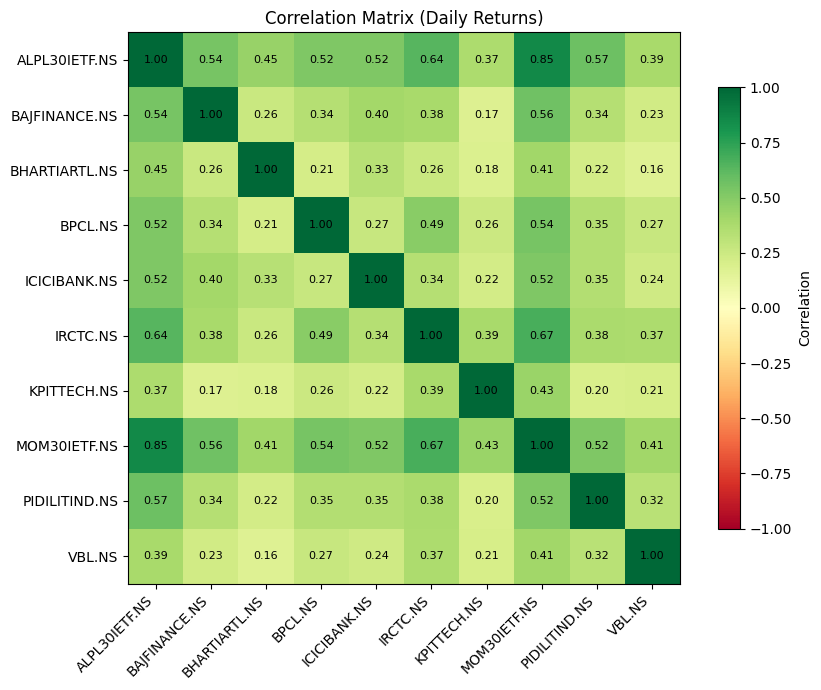

In [11]:
## 5. Exploratory Analysis
# Summary statistics table
summary_stats = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility,
    "Sharpe (vs risk-free)": (annual_returns - RISK_FREE_RATE) / annual_volatility,
})
summary_stats.sort_values("Sharpe (vs risk-free)", ascending=False)

correlation_matrix = daily_returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(correlation_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_yticklabels(tickers)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation Matrix (Daily Returns)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
plt.tight_layout()
plt.show()

In [12]:
print("Annualized Covariance Matrix:")
annual_cov.round(4)
# Calendar-year returns per asset, for a quick sanity check against known market moves
annual_return_table = prices_clean.resample("YE").last().pct_change().dropna()
annual_return_table.index = annual_return_table.index.year
(annual_return_table * 100).round(2)

Annualized Covariance Matrix:


,ALPL30IETF.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,ICICIBANK.NS,IRCTC.NS,KPITTECH.NS,MOM30IETF.NS,PIDILITIND.NS,VBL.NS
Date,,,,,,,,,,
2025,-3.16,45.52,33.72,38.74,5.59,-11.89,-19.41,-4.98,2.79,-23.06
2026,-1.26,3.84,-10.95,-16.87,4.25,-25.65,-52.23,-1.23,8.30,4.48


In [13]:
## 6. Current Portfolio Analysis

def calculate_current_weights(holdings_df, latest_prices):
    """Compute current portfolio weights from share counts and latest prices."""
    values = holdings_df["shares"] * latest_prices
    weights = values / values.sum()
    return weights, values

latest_prices = prices_clean.iloc[-1]
current_weights, current_values = calculate_current_weights(holdings_df, latest_prices)

current_portfolio_table = pd.DataFrame({
    "Shares": holdings_df["shares"],
    "Avg Price": holdings_df["avg_price"],
    "Latest Price": latest_prices,
    "Market Value": current_values,
    "Weight": current_weights,
})
current_portfolio_table["Weight"] = current_portfolio_table["Weight"].map("{:.2%}".format)
current_portfolio_table.sort_values("Market Value", ascending=False)

def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=RISK_FREE_RATE):
    """Return (expected annual return, annual volatility, Sharpe ratio) for a weight vector."""
    weights = np.array(weights)
    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(weights.T @ cov_matrix.values @ weights)
    sharpe = (port_return - risk_free_rate) / port_volatility
    return port_return, port_volatility, sharpe


current_weights_array = current_weights.reindex(tickers).values
current_return, current_volatility, current_sharpe = portfolio_performance(
    current_weights_array, annual_returns, annual_cov
)

print(f"Current Portfolio — Expected Annual Return: {current_return:.2%}")
print(f"Current Portfolio — Annual Volatility:       {current_volatility:.2%}")
print(f"Current Portfolio — Sharpe Ratio:             {current_sharpe:.2f}")

Current Portfolio — Expected Annual Return: 2.08%
Current Portfolio — Annual Volatility:       15.85%
Current Portfolio — Sharpe Ratio:             -0.30


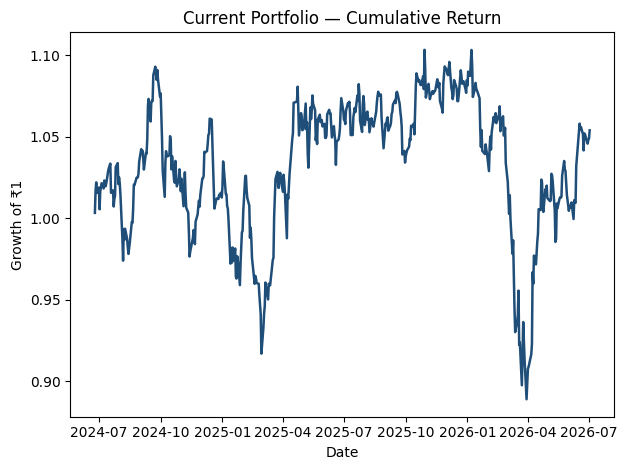

In [14]:
# Cumulative return of the current portfolio (holding these weights static over the lookback period)
weighted_daily_returns = daily_returns[tickers].dot(current_weights_array)
cumulative_return = (1 + weighted_daily_returns).cumprod()

fig, ax = plt.subplots()
ax.plot(cumulative_return.index, cumulative_return.values, color="#1f4e79", linewidth=1.8)
ax.set_title("Current Portfolio — Cumulative Return")
ax.set_ylabel("Growth of ₹1")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

In [16]:
from pypfopt import EfficientFrontier

In [17]:
## 7. Optimization Model 1 — Mean-Variance Optimization (Markowitz)

def run_mean_variance_optimization(mean_returns, cov_matrix, target_return):
    """Minimum-volatility portfolio for a given target return. Long-only, fully invested."""
    ef = EfficientFrontier(mean_returns, cov_matrix, weight_bounds=(0, 1))
    try:
        ef.efficient_return(target_return=target_return)
    except Exception as e:
        print(f"Mean-variance optimization failed: {e}")
        return None, None, None, None
    weights = pd.Series(ef.clean_weights())
    ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
    return weights, ret, vol, sharpe


mv_weights, mv_return, mv_volatility, mv_sharpe = run_mean_variance_optimization(
    annual_returns, annual_cov, target_return=current_return
)

print(f"Mean-Variance Portfolio — Expected Return: {mv_return:.2%}")
print(f"Mean-Variance Portfolio — Volatility:      {mv_volatility:.2%}")
print(f"Mean-Variance Portfolio — Sharpe Ratio:     {mv_sharpe:.2f}")
mv_weights[mv_weights > 0.0001].sort_values(ascending=False)

Mean-Variance Portfolio — Expected Return: 2.79%
Mean-Variance Portfolio — Volatility:      12.84%
Mean-Variance Portfolio — Sharpe Ratio:     -0.32


,0
ALPL30IETF.NS,0.62564
ICICIBANK.NS,0.14896
BHARTIARTL.NS,0.13103
PIDILITIND.NS,0.09437


In [18]:
## 8. Optimization Model 2 — Modern Portfolio Theory (Maximum Sharpe Portfolio)

def simulate_random_portfolios(mean_returns, cov_matrix, n_portfolios, risk_free_rate=RISK_FREE_RATE):
    """Generate random long-only portfolios for the efficient frontier scatter plot."""
    n_assets = len(mean_returns)
    results = np.zeros((3, n_portfolios))
    all_weights = np.zeros((n_portfolios, n_assets))

    for i in range(n_portfolios):
        w = np.random.random(n_assets)
        w /= w.sum()
        all_weights[i] = w
        port_return, port_vol, sharpe = portfolio_performance(w, mean_returns, cov_matrix, risk_free_rate)
        results[0, i] = port_return
        results[1, i] = port_vol
        results[2, i] = sharpe

    return results, all_weights


random_results, random_weights = simulate_random_portfolios(
    annual_returns, annual_cov, N_RANDOM_PORTFOLIOS
)

def run_max_sharpe_optimization(mean_returns, cov_matrix):
    """Long-only portfolio that maximizes the Sharpe ratio."""
    ef = EfficientFrontier(mean_returns, cov_matrix, weight_bounds=(0, 1))
    try:
        ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
    except Exception as e:
        print(f"Max Sharpe optimization failed: {e}")
        return None, None, None, None
    weights = pd.Series(ef.clean_weights())
    ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
    return weights, ret, vol, sharpe


max_sharpe_weights, max_sharpe_return, max_sharpe_volatility, max_sharpe_sharpe = run_max_sharpe_optimization(
    annual_returns, annual_cov
)

print(f"Max Sharpe Portfolio — Expected Return: {max_sharpe_return:.2%}")
print(f"Max Sharpe Portfolio — Volatility:      {max_sharpe_volatility:.2%}")
print(f"Max Sharpe Portfolio — Sharpe Ratio:     {max_sharpe_sharpe:.2f}")
max_sharpe_weights[max_sharpe_weights > 0.0001].sort_values(ascending=False)

Max Sharpe Portfolio — Expected Return: 18.47%
Max Sharpe Portfolio — Volatility:      19.44%
Max Sharpe Portfolio — Sharpe Ratio:     0.60


,0
BAJFINANCE.NS,0.50161
BHARTIARTL.NS,0.49839


In [19]:
## 9. Optimization Model 3 — Minimum Variance Portfolio

def run_min_variance_optimization(mean_returns, cov_matrix):
    """Long-only portfolio that minimizes volatility, with no return target."""
    ef = EfficientFrontier(mean_returns, cov_matrix, weight_bounds=(0, 1))
    try:
        ef.min_volatility()
    except Exception as e:
        print(f"Min variance optimization failed: {e}")
        return None, None, None, None
    weights = pd.Series(ef.clean_weights())
    ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
    return weights, ret, vol, sharpe


min_var_weights, min_var_return, min_var_volatility, min_var_sharpe = run_min_variance_optimization(
    annual_returns, annual_cov
)

print(f"Min Variance Portfolio — Expected Return: {min_var_return:.2%}")
print(f"Min Variance Portfolio — Volatility:      {min_var_volatility:.2%}")
print(f"Min Variance Portfolio — Sharpe Ratio:     {min_var_sharpe:.2f}")
min_var_weights[min_var_weights > 0.0001].sort_values(ascending=False)

Min Variance Portfolio — Expected Return: 2.79%
Min Variance Portfolio — Volatility:      12.84%
Min Variance Portfolio — Sharpe Ratio:     -0.32


,0
ALPL30IETF.NS,0.62564
ICICIBANK.NS,0.14896
BHARTIARTL.NS,0.13103
PIDILITIND.NS,0.09437


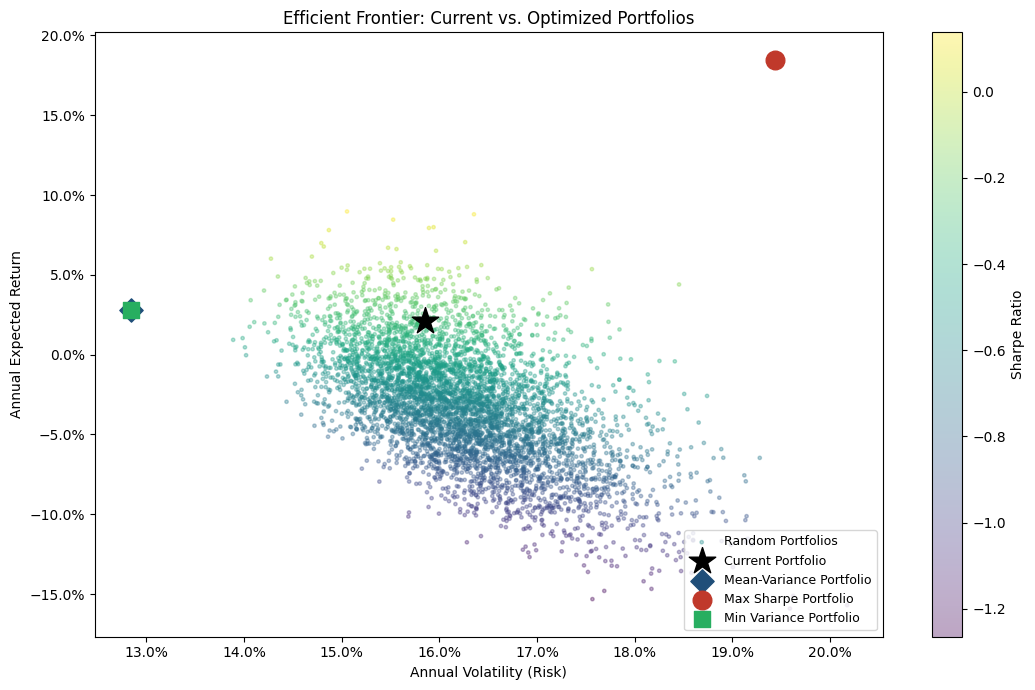

In [29]:
### Efficient Frontier — Current vs. Optimized Portfolios

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    random_results[1], random_results[0], c=random_results[2],
    cmap="viridis", s=6, alpha=0.35, label="Random Portfolios"
)
fig.colorbar(scatter, ax=ax, label="Sharpe Ratio")

ax.scatter(current_volatility, current_return, marker="*", s=400, color="black",
           label="Current Portfolio", zorder=5)
ax.scatter(mv_volatility, mv_return, marker="D", s=140, color="#1f4e79",
           label="Mean-Variance Portfolio", zorder=5)
ax.scatter(max_sharpe_volatility, max_sharpe_return, marker="o", s=180, color="#c0392b",
           label="Max Sharpe Portfolio", zorder=5)
ax.scatter(min_var_volatility, min_var_return, marker="s", s=140, color="#27ae60",
           label="Min Variance Portfolio", zorder=5)

ax.set_xlabel("Annual Volatility (Risk)")
ax.set_ylabel("Annual Expected Return")
ax.set_title("Efficient Frontier: Current vs. Optimized Portfolios")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
from pypfopt.black_litterman import BlackLittermanModel, market_implied_prior_returns

In [33]:
## 10. Optimization Model 4 — Black-Litterman Model

def get_market_caps(ticker_list):
    """Fetch market caps for the market-implied prior. Falls back to equal weighting on failure."""
    caps = {}
    missing = []
    for t in ticker_list:
        try:
            info = yf.Ticker(t).fast_info
            cap = info.get("market_cap") if hasattr(info, "get") else None
            if not cap:
                cap = yf.Ticker(t).info.get("marketCap")
            if cap:
                caps[t] = cap
            else:
                missing.append(t)
        except Exception:
            missing.append(t)

    if missing:
        print(f"WARNING: market cap unavailable for {missing}. Using an equal-weight fallback for those tickers.")
        avg_cap = np.mean(list(caps.values())) if caps else 1.0
        for t in missing:
            caps[t] = avg_cap

    return pd.Series(caps).reindex(ticker_list)


market_caps = get_market_caps(tickers)
market_prior = market_implied_prior_returns(
    market_caps,
    risk_aversion=2.5,
    cov_matrix=annual_cov,
    risk_free_rate=RISK_FREE_RATE,
)

print("Market-implied equilibrium returns:")
market_prior.round(4)

Market-implied equilibrium returns:


,0
ALPL30IETF.NS,0.1092
BAJFINANCE.NS,0.1411
BHARTIARTL.NS,0.1244
BPCL.NS,0.1231
ICICIBANK.NS,0.1200
IRCTC.NS,0.1185
KPITTECH.NS,0.1186
MOM30IETF.NS,0.1260
PIDILITIND.NS,0.1075
VBL.NS,0.1214


In [35]:
### Your Market Views

# ---------------------------------------------------------------------------
# EDIT YOUR VIEWS HERE — every ticker in the portfolio has a placeholder view below.
# Replace the numbers with your own conviction. Delete a line entirely if you
# have no view on that name (Black-Litterman will just fall back to the
# market-implied return for it).
# ---------------------------------------------------------------------------

# Absolute views: {ticker: expected annual return}
# EDIT every value below — these are placeholders, not real forecasts.
absolute_views = {
    "ALPL30IETF.NS": 0.12,
    "BAJFINANCE.NS": 0.18,
    "BHARTIARTL.NS": 0.15,
    "BPCL.NS":       0.10,
    "ICICIBANK.NS":  0.16,
    "IRCTC.NS":      0.14,
    "KPITTECH.NS":   0.20,
    "MOM30IETF.NS":  0.13,
    "PIDILITIND.NS": 0.14,
    "RIR.NS":        0.12,
    "VBL.NS":        0.17,
}

# Relative views: (ticker_outperforming, ticker_underperforming, outperformance_pct, confidence)
# Chained so every ticker appears at least once — EDIT the pairings, spreads,
# and confidences to reflect your actual thesis.
relative_views = [
    ("BAJFINANCE.NS", "BPCL.NS",       0.03, 0.5),
    ("ICICIBANK.NS",  "IRCTC.NS",      0.02, 0.5),
    ("BHARTIARTL.NS", "KPITTECH.NS",   0.03, 0.5),
    ("PIDILITIND.NS", "RIR.NS",        0.02, 0.5),
    ("VBL.NS",        "MOM30IETF.NS",  0.04, 0.5),
    ("ALPL30IETF.NS", "VBL.NS",        0.01, 0.5),
]

def build_bl_views(tickers, absolute_views, relative_views):
    """Convert simple view dictionaries/tuples into the Q vector, P matrix,
    and confidence list that PyPortfolioOpt's Black-Litterman model expects."""
    Q = []
    P = []
    confidences = []

    for ticker, view_return in absolute_views.items():
        if ticker not in tickers:
            print(f"WARNING: view on {ticker} skipped — not in portfolio universe.")
            continue
        row = [1 if t == ticker else 0 for t in tickers]
        P.append(row)
        Q.append(view_return)
        confidences.append(0.5)

    for winner, loser, spread, confidence in relative_views:
        if winner not in tickers or loser not in tickers:
            print(f"WARNING: relative view ({winner} vs {loser}) skipped — ticker not in portfolio universe.")
            continue
        row = [0] * len(tickers)
        row[tickers.index(winner)] = 1
        row[tickers.index(loser)] = -1
        P.append(row)
        Q.append(spread)
        confidences.append(confidence)

    return np.array(Q), np.array(P), confidences


Q, P, view_confidences = build_bl_views(tickers, absolute_views, relative_views)

if len(Q) == 0:
    print("No views specified — Black-Litterman posterior will equal the market-implied prior.")

In [36]:
def run_black_litterman(mean_returns_prior, cov_matrix, Q, P, confidences, market_caps):
    """Blend market equilibrium returns with personal views to get posterior returns and optimal weights."""
    if len(Q) == 0:
        posterior_returns = mean_returns_prior
    else:
        bl = BlackLittermanModel(
            cov_matrix,
            pi=mean_returns_prior,
            Q=Q,
            P=P,
            omega="idzorek",
            view_confidences=confidences,
        )
        posterior_returns = bl.bl_returns()

    ef = EfficientFrontier(posterior_returns, cov_matrix, weight_bounds=(0, 1))
    try:
        ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
    except Exception as e:
        print(f"Black-Litterman optimization failed: {e}")
        return posterior_returns, None, None, None, None

    weights = pd.Series(ef.clean_weights())
    ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
    return posterior_returns, weights, ret, vol, sharpe


bl_posterior_returns, bl_weights, bl_return, bl_volatility, bl_sharpe = run_black_litterman(
    market_prior, annual_cov, Q, P, view_confidences, market_caps
)

print("Posterior expected returns (Black-Litterman):")
print(bl_posterior_returns.round(4))
print()
print(f"Black-Litterman Portfolio — Expected Return: {bl_return:.2%}")
print(f"Black-Litterman Portfolio — Volatility:      {bl_volatility:.2%}")
print(f"Black-Litterman Portfolio — Sharpe Ratio:     {bl_sharpe:.2f}")
bl_weights[bl_weights > 0.0001].sort_values(ascending=False)

Posterior expected returns (Black-Litterman):
ALPL30IETF.NS    0.1219
BAJFINANCE.NS    0.1630
BHARTIARTL.NS    0.1453
BPCL.NS          0.1247
ICICIBANK.NS     0.1449
IRCTC.NS         0.1319
KPITTECH.NS      0.1476
MOM30IETF.NS     0.1395
PIDILITIND.NS    0.1272
VBL.NS           0.1480
dtype: float64

Black-Litterman Portfolio — Expected Return: 14.48%
Black-Litterman Portfolio — Volatility:      14.66%
Black-Litterman Portfolio — Sharpe Ratio:     0.52


,0
ICICIBANK.NS,0.31850
BHARTIARTL.NS,0.28231
BAJFINANCE.NS,0.13782
PIDILITIND.NS,0.11281
VBL.NS,0.06637
ALPL30IETF.NS,0.04456
KPITTECH.NS,0.03763


In [37]:
## 11. Comparison Table — All Portfolios

comparison_table = pd.DataFrame({
    "Current Portfolio":      [current_return, current_volatility, current_sharpe],
    "Mean-Variance Portfolio": [mv_return, mv_volatility, mv_sharpe],
    "Max Sharpe Portfolio":    [max_sharpe_return, max_sharpe_volatility, max_sharpe_sharpe],
    "Min Variance Portfolio":  [min_var_return, min_var_volatility, min_var_sharpe],
    "Black-Litterman Portfolio": [bl_return, bl_volatility, bl_sharpe],
}, index=["Expected Return", "Volatility", "Sharpe Ratio"]).T

comparison_display = comparison_table.copy()
comparison_display["Expected Return"] = comparison_display["Expected Return"].map("{:.2%}".format)
comparison_display["Volatility"] = comparison_display["Volatility"].map("{:.2%}".format)
comparison_display["Sharpe Ratio"] = comparison_display["Sharpe Ratio"].round(2)
comparison_display

,Expected Return,Volatility,Sharpe Ratio
Current Portfolio,2.08%,15.85%,-0.30
Mean-Variance Portfolio,2.79%,12.84%,-0.32
Max Sharpe Portfolio,18.47%,19.44%,0.60
Min Variance Portfolio,2.79%,12.84%,-0.32
Black-Litterman Portfolio,14.48%,14.66%,0.52


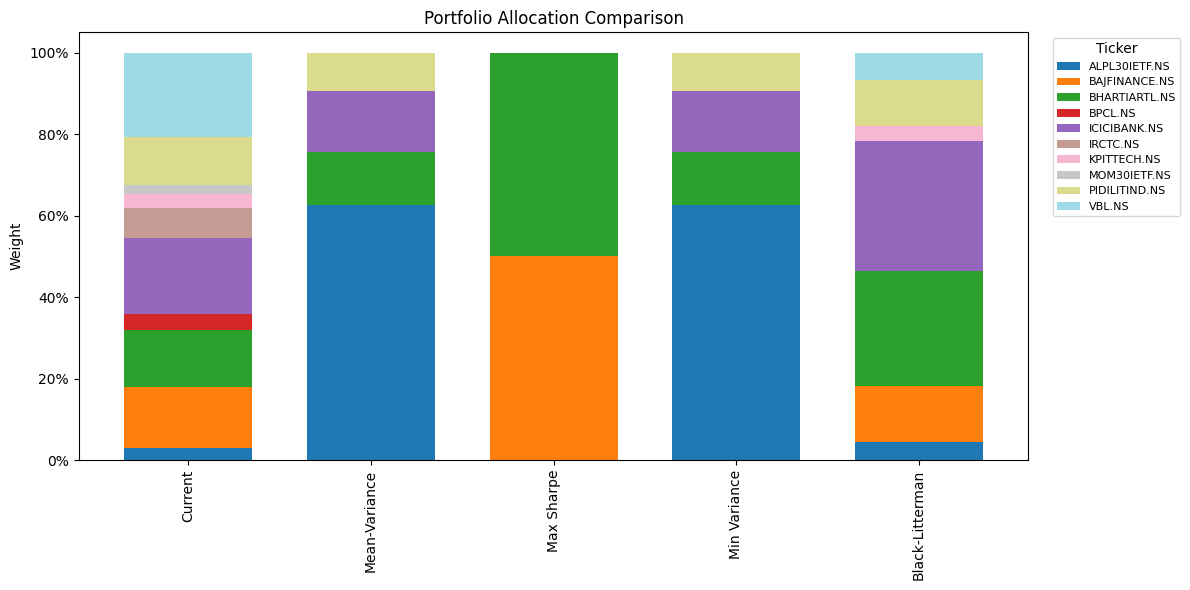

In [38]:
## 12. Visualizations

# Portfolio allocation comparison — stacked weights across all five strategies
weights_matrix = pd.DataFrame({
    "Current": current_weights.reindex(tickers).fillna(0),
    "Mean-Variance": mv_weights.reindex(tickers).fillna(0),
    "Max Sharpe": max_sharpe_weights.reindex(tickers).fillna(0),
    "Min Variance": min_var_weights.reindex(tickers).fillna(0),
    "Black-Litterman": bl_weights.reindex(tickers).fillna(0),
})

fig, ax = plt.subplots(figsize=(12, 6))
weights_matrix.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.7)
ax.set_ylabel("Weight")
ax.set_title("Portfolio Allocation Comparison")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

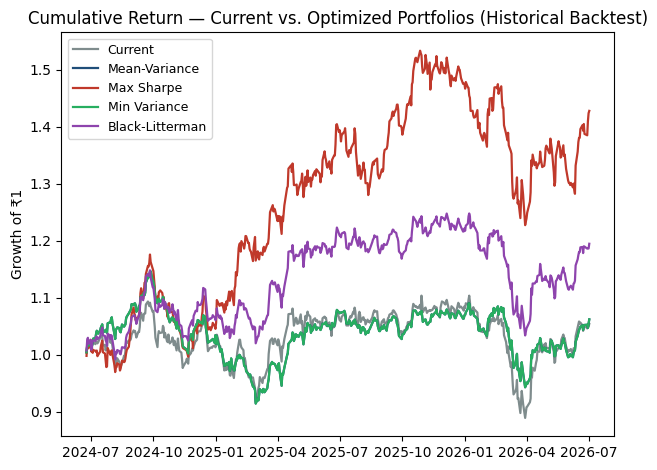

In [40]:
# Cumulative returns of every strategy, applied retroactively to the historical window
fig, ax = plt.subplots()

strategy_weight_map = {
    "Current": current_weights_array,
    "Mean-Variance": mv_weights.reindex(tickers).values,
    "Max Sharpe": max_sharpe_weights.reindex(tickers).values,
    "Min Variance": min_var_weights.reindex(tickers).values,
    "Black-Litterman": bl_weights.reindex(tickers).values,
}

colors = ["#7f8c8d", "#1f4e79", "#c0392b", "#27ae60", "#8e44ad"]

for (name, w), color in zip(strategy_weight_map.items(), colors):
    cum_ret = (1 + daily_returns[tickers].dot(w)).cumprod()
    ax.plot(cum_ret.index, cum_ret.values, label=name, color=color, linewidth=1.6)

ax.set_title("Cumulative Return — Current vs. Optimized Portfolios (Historical Backtest)")
ax.set_ylabel("Growth of ₹1")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

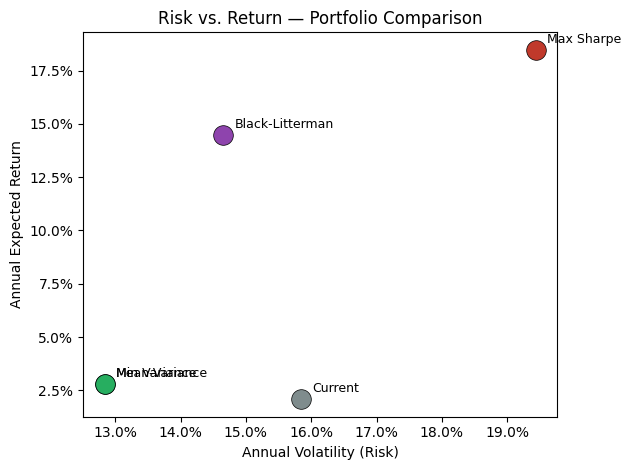

In [41]:
# Risk vs. return scatter for all five strategies
fig, ax = plt.subplots()

points = {
    "Current": (current_volatility, current_return),
    "Mean-Variance": (mv_volatility, mv_return),
    "Max Sharpe": (max_sharpe_volatility, max_sharpe_return),
    "Min Variance": (min_var_volatility, min_var_return),
    "Black-Litterman": (bl_volatility, bl_return),
}

for (name, (vol, ret)), color in zip(points.items(), colors):
    ax.scatter(vol, ret, s=200, color=color, label=name, edgecolor="black", linewidth=0.5)
    ax.annotate(name, (vol, ret), textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel("Annual Volatility (Risk)")
ax.set_ylabel("Annual Expected Return")
ax.set_title("Risk vs. Return — Portfolio Comparison")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [42]:
## 13. Final Recommendation

def generate_recommendation_summary(comparison_table):
    """Print a plain-language summary comparing all strategies to the current portfolio."""
    current = comparison_table.loc["Current Portfolio"]
    best_sharpe_strategy = comparison_table["Sharpe Ratio"].idxmax()
    lowest_vol_strategy = comparison_table["Volatility"].idxmin()
    highest_return_strategy = comparison_table["Expected Return"].idxmax()

    print("=" * 70)
    print("PORTFOLIO OPTIMIZATION SUMMARY")
    print("=" * 70)
    print(f"\nCurrent portfolio: {current['Expected Return']:.2%} return, "
          f"{current['Volatility']:.2%} volatility, Sharpe {current['Sharpe Ratio']:.2f}\n")

    for name, row in comparison_table.iterrows():
        if name == "Current Portfolio":
            continue
        return_diff = row["Expected Return"] - current["Expected Return"]
        vol_diff = row["Volatility"] - current["Volatility"]
        print(f"{name}: {return_diff:+.2%} return, {vol_diff:+.2%} volatility "
              f"vs. current (Sharpe {row['Sharpe Ratio']:.2f})")

    print(f"\nBest risk-adjusted return: {best_sharpe_strategy} (Sharpe {comparison_table.loc[best_sharpe_strategy, 'Sharpe Ratio']:.2f})")
    print(f"Lowest risk:               {lowest_vol_strategy} ({comparison_table.loc[lowest_vol_strategy, 'Volatility']:.2%} volatility)")
    print(f"Highest expected return:   {highest_return_strategy} ({comparison_table.loc[highest_return_strategy, 'Expected Return']:.2%})")
    print("=" * 70)


generate_recommendation_summary(comparison_table)

PORTFOLIO OPTIMIZATION SUMMARY

Current portfolio: 2.08% return, 15.85% volatility, Sharpe -0.30

Mean-Variance Portfolio: +0.71% return, -3.01% volatility vs. current (Sharpe -0.32)
Max Sharpe Portfolio: +16.39% return, +3.58% volatility vs. current (Sharpe 0.60)
Min Variance Portfolio: +0.71% return, -3.01% volatility vs. current (Sharpe -0.32)
Black-Litterman Portfolio: +12.40% return, -1.20% volatility vs. current (Sharpe 0.52)

Best risk-adjusted return: Max Sharpe Portfolio (Sharpe 0.60)
Lowest risk:               Mean-Variance Portfolio (12.84% volatility)
Highest expected return:   Max Sharpe Portfolio (18.47%)


In [43]:
## 13. Rebalancing Engine — What To Buy / Sell

TARGET_STRATEGY = "Black-Litterman"

# Ignore trades smaller than this weight difference (avoids noisy, tiny trades)
REBALANCE_THRESHOLD = 0.01  # 1% of portfolio


def build_rebalancing_plan(current_values, weights_matrix, target_strategy, latest_prices, threshold):
    """Compare current holdings to a target allocation and produce a simple buy/sell plan."""
    total_value = current_values.sum()

    current_w = weights_matrix["Current"]
    target_w = weights_matrix[target_strategy]

    target_values = target_w * total_value
    value_change = target_values - current_values

    plan = pd.DataFrame({
        "Current Weight": current_w,
        "Target Weight": target_w,
        "Current Value": current_values,
        "Target Value": target_values,
        "Value Change (Rs)": value_change,
    })

    # Approximate shares to trade at the latest available price (rounded to whole shares)
    plan["Approx Shares to Trade"] = (value_change / latest_prices).round(0).astype(int)

    def classify_action(row):
        if abs(row["Current Weight"] - row["Target Weight"]) < threshold:
            return "HOLD"
        return "BUY" if row["Value Change (Rs)"] > 0 else "SELL"

    plan["Action"] = plan.apply(classify_action, axis=1)

    # Zero out the trade amount for anything classified as HOLD, so the plan is unambiguous
    plan.loc[plan["Action"] == "HOLD", ["Value Change (Rs)", "Approx Shares to Trade"]] = 0

    return plan.sort_values("Value Change (Rs)")


rebalancing_plan = build_rebalancing_plan(
    current_values, weights_matrix, TARGET_STRATEGY, latest_prices, REBALANCE_THRESHOLD
)

# Readable display version
display_plan = rebalancing_plan.copy()
display_plan["Current Weight"] = display_plan["Current Weight"].map("{:.2%}".format)
display_plan["Target Weight"] = display_plan["Target Weight"].map("{:.2%}".format)
display_plan["Current Value"] = display_plan["Current Value"].map("Rs {:,.0f}".format)
display_plan["Target Value"] = display_plan["Target Value"].map("Rs {:,.0f}".format)
display_plan["Value Change (Rs)"] = display_plan["Value Change (Rs)"].map("Rs {:,.0f}".format)

print(f"Rebalancing toward: {TARGET_STRATEGY} Portfolio")
print(f"Total portfolio value: Rs {current_values.sum():,.0f}\n")
display_plan[["Action", "Current Weight", "Target Weight", "Current Value", "Target Value",
              "Value Change (Rs)", "Approx Shares to Trade"]]

Rebalancing toward: Black-Litterman Portfolio
Total portfolio value: Rs 135,897



,Action,Current Weight,Target Weight,Current Value,Target Value,Value Change (Rs),Approx Shares to Trade
VBL.NS,SELL,20.67%,6.64%,"Rs 28,086","Rs 9,020","Rs -19,066",-37
IRCTC.NS,SELL,7.45%,0.00%,"Rs 10,124",Rs 0,"Rs -10,124",-20
BPCL.NS,SELL,4.11%,0.00%,"Rs 5,588",Rs 0,"Rs -5,588",-18
MOM30IETF.NS,SELL,2.30%,0.00%,"Rs 3,129",Rs 0,"Rs -3,129",-100
BAJFINANCE.NS,SELL,14.99%,13.78%,"Rs 20,368","Rs 18,729","Rs -1,639",-2
KPITTECH.NS,HOLD,3.29%,3.76%,"Rs 4,470","Rs 5,114",Rs 0,0
PIDILITIND.NS,HOLD,11.81%,11.28%,"Rs 16,054","Rs 15,331",Rs 0,0
ALPL30IETF.NS,BUY,3.04%,4.46%,"Rs 4,128","Rs 6,056","Rs 1,928",70
ICICIBANK.NS,BUY,18.54%,31.85%,"Rs 25,200","Rs 43,283","Rs 18,083",13
BHARTIARTL.NS,BUY,13.80%,28.23%,"Rs 18,750","Rs 38,365","Rs 19,615",10
